In [1]:
import os
import itertools
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_ch, out_ch)

    def forward(self, x_up, x_skip):
        x_up = self.up(x_up)
        dy = x_skip.size(2) - x_up.size(2)
        dx = x_skip.size(3) - x_up.size(3)
        x_up = F.pad(x_up, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        return self.conv(torch.cat([x_skip, x_up], dim=1))


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ConvBlock(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = ConvBlock(512, 1024)
        # Decoder
        self.dec4 = UpBlock(1024, 512)
        self.dec3 = UpBlock(512, 256)
        self.dec2 = UpBlock(256, 128)
        self.dec1 = UpBlock(128, 64)
        # Output head
        self.head = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b  = self.bottleneck(self.pool4(e4))

        d4 = self.dec4(b, e4)
        d3 = self.dec3(d4, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)
        return self.head(d1)

In [4]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [5]:
class Trainer:
    def __init__(self, config, model_name='UNet'):
        self.config = config
        self.model_name = model_name
        self.history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_f1': []}

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        if self.model_name == 'UNet':
            self.model = UNet().to(config.device)
        elif self.model_name == 'ResUNet':
            self.model = ResUNet().to(config.device)
        else:
            raise ValueError(f"Unknown model: {self.model_name}")

        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        self.history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_f1': []}

        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_iou'].append(val_iou)
            self.history['val_f1'].append(val_f1)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        self.plot_training_history()

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()
        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def plot_training_history(self):
        epochs = range(1, len(self.history['train_loss']) + 1)
        fig, ax1 = plt.subplots(figsize=(12, 5))

        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss', color='tab:red')
        ax1.plot(epochs, self.history['train_loss'], label='Train Loss', color='tab:red', linestyle='--')
        ax1.plot(epochs, self.history['val_loss'], label='Val Loss', color='tab:orange')
        ax1.tick_params(axis='y', labelcolor='tab:red')
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        ax2.set_ylabel('Metrics', color='tab:blue')
        ax2.plot(epochs, self.history['val_iou'], label='Val IoU', color='tab:blue')
        ax2.plot(epochs, self.history['val_f1'], label='Val F1', color='tab:cyan')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
        ax2.legend(loc='upper right')

        plt.title(f'Training History — {self.model_name}')
        fig.tight_layout()
        plt.show()

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader, desc='Training', leave=False):
            images, masks = images.to(self.config.device), masks.to(self.config.device)
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()
            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader, desc='Validating', leave=False):
                images, masks = images.to(self.config.device), masks.to(self.config.device)
                outputs = self.model(images)
                val_loss += self.criterion(outputs, masks).item()

                preds = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                gt = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(preds)):
                    iou_scores.append(jaccard_score(gt[i].flatten(), preds[i].flatten(), average='binary', zero_division=1))
                    f1_scores.append(f1_score(gt[i].flatten(), preds[i].flatten(), average='binary', zero_division=1))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader, desc='Testing', leave=False):
                images, masks = images.to(self.config.device), masks.to(self.config.device)
                outputs = self.model(images)
                test_loss += self.criterion(outputs, masks).item()

                preds = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                gt = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(preds)):
                    iou_scores.append(jaccard_score(gt[i].flatten(), preds[i].flatten(), average='binary', zero_division=1))
                    f1_scores.append(f1_score(gt[i].flatten(), preds[i].flatten(), average='binary', zero_division=1))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = torch.sigmoid(self.model(img_tensor)).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                display_img = (img.permute(1, 2, 0).cpu().numpy() * 0.5) + 0.5
                axes[i, 0].imshow(np.clip(display_img, 0, 1))
                axes[i, 0].set_title('Image')
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap='gray')
                axes[i, 1].set_title('Ground Truth')
                axes[i, 2].imshow(output, cmap='gray')
                axes[i, 2].set_title('Predicted Mask')

            plt.tight_layout()
            plt.show()

    def tune_hyperparameters(self, param_grid, trial_epochs=5):
        best_val_f1, best_params = -1.0, {}
        base_cfg = {attr: getattr(self.config, attr)
                    for attr in dir(self.config)
                    if not attr.startswith('__') and not callable(getattr(self.config, attr))}

        keys = list(param_grid.keys())
        all_combos = list(itertools.product(*param_grid.values()))

        print('Starting hyperparameter tuning...')
        for idx, combo in enumerate(all_combos):
            current = dict(zip(keys, combo))
            print(f'\nTrial {idx+1}/{len(all_combos)}: {current}')

            trial_cfg = Config()
            for k, v in base_cfg.items():
                setattr(trial_cfg, k, v)
            for k, v in current.items():
                setattr(trial_cfg, k, v)

            self.config = trial_cfg
            self.model = (UNet() if self.model_name == 'UNet' else ResUNet()).to(self.config.device)
            self.optimizer = optim.Adam(self.model.parameters(), lr=self.config.learning_rate)
            self.setup_dataloader()

            val_f1 = 0.0
            for ep in range(trial_epochs):
                self.train()
                _, _, val_f1 = self.validate()

            if val_f1 > best_val_f1:
                best_val_f1, best_params = val_f1, current
                print(f'  New best: {best_params} — F1: {best_val_f1:.4f}')

        print(f'\nTuning done. Best config: {best_params}, F1: {best_val_f1:.4f}')
        for k, v in best_params.items():
            setattr(self.config, k, v)
        self.model = (UNet() if self.model_name == 'UNet' else ResUNet()).to(self.config.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.config.learning_rate)
        self.setup_dataloader()
        print('Trainer updated with best config.')

In [6]:
trainer = Trainer(config, model_name='UNet')

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 792M/792M [00:36<00:00, 21.7MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 9.99MB/s]


In [ ]:
param_grid = {
    'learning_rate': [0.001, 0.0001, 0.00001],
    'batch_size': [16, 32, 64]
}

trainer.tune_hyperparameters(param_grid, trial_epochs=5)

Starting hyperparameter tuning...

Trial 1/9: {'learning_rate': 0.001, 'batch_size': 16}


  New best: {'learning_rate': 0.001, 'batch_size': 16} — F1: 0.8979

Trial 2/9: {'learning_rate': 0.001, 'batch_size': 32}


  New best: {'learning_rate': 0.001, 'batch_size': 32} — F1: 0.9036

Trial 3/9: {'learning_rate': 0.001, 'batch_size': 64}


  New best: {'learning_rate': 0.001, 'batch_size': 64} — F1: 0.9071

Trial 4/9: {'learning_rate': 0.0001, 'batch_size': 16}


  New best: {'learning_rate': 0.0001, 'batch_size': 16} — F1: 0.9219

Trial 5/9: {'learning_rate': 0.0001, 'batch_size': 32}


  New best: {'learning_rate': 0.0001, 'batch_size': 32} — F1: 0.9264

Trial 6/9: {'learning_rate': 0.0001, 'batch_size': 64}



Trial 7/9: {'learning_rate': 1e-05, 'batch_size': 16}



Trial 8/9: {'learning_rate': 1e-05, 'batch_size': 32}



Trial 9/9: {'learning_rate': 1e-05, 'batch_size': 64}



Tuning done. Best config: {'learning_rate': 0.0001, 'batch_size': 32}, F1: 0.9264
Trainer updated with best config.


learning_rate 0.0001 оказался оптимальным — не перепрыгивает минимумы, но и не застревает в плоских зонах.

batch_size 32 дал лучший результат: шумный градиент помогает выбираться из плохих локальных минимумов.

Epoch 1 / 15, Train Loss: 0.4910, Val Loss: 0.4111, Val IoU: 0.7884, Val F1-score: 0.8760


Epoch 2 / 15, Train Loss: 0.3623, Val Loss: 0.4230, Val IoU: 0.7463, Val F1-score: 0.8450


Epoch 3 / 15, Train Loss: 0.3154, Val Loss: 0.3048, Val IoU: 0.8568, Val F1-score: 0.9187


Epoch 4 / 15, Train Loss: 0.2802, Val Loss: 0.2884, Val IoU: 0.8624, Val F1-score: 0.9223


Epoch 5 / 15, Train Loss: 0.2553, Val Loss: 0.2798, Val IoU: 0.8582, Val F1-score: 0.9194


...

Epoch 11 / 15, Train Loss: 0.1466, Val Loss: 0.2324, Val IoU: 0.8803, Val F1-score: 0.9329


Epoch 12 / 15, Train Loss: 0.1388, Val Loss: 0.2171, Val IoU: 0.8807, Val F1-score: 0.9332


Epoch 13 / 15, Train Loss: 0.1260, Val Loss: 0.2496, Val IoU: 0.8684, Val F1-score: 0.9255


Epoch 14 / 15, Train Loss: 0.1217, Val Loss: 0.2437, Val IoU: 0.8719, Val F1-score: 0.9273


Epoch 15 / 15, Train Loss: 0.1187, Val Loss: 0.2805, Val IoU: 0.8617, Val F1-score: 0.9219


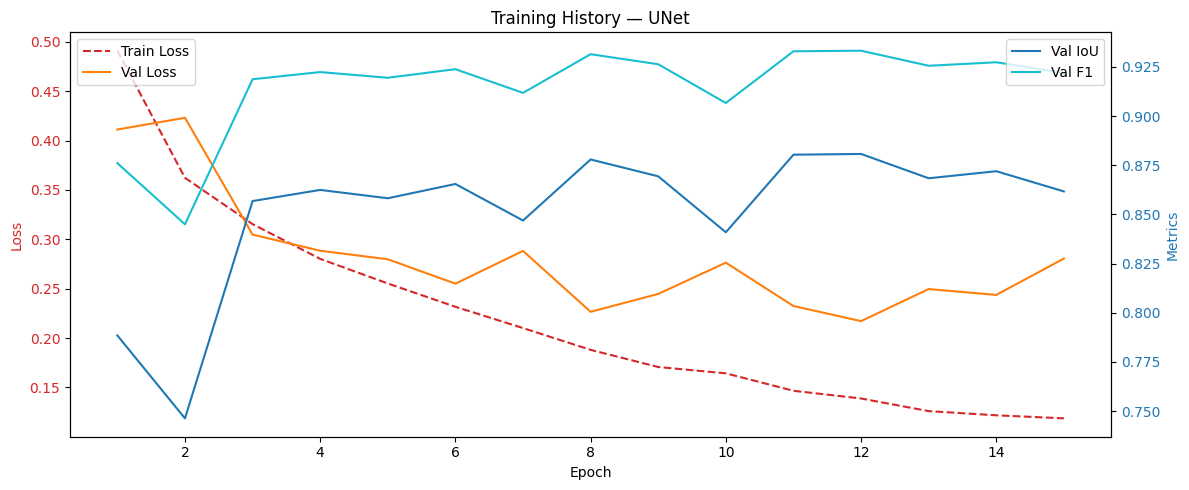

Testing...


Test Loss: 0.2849, Test IoU: 0.8585, Test F1-score: 0.9188


In [ ]:
trainer.run()

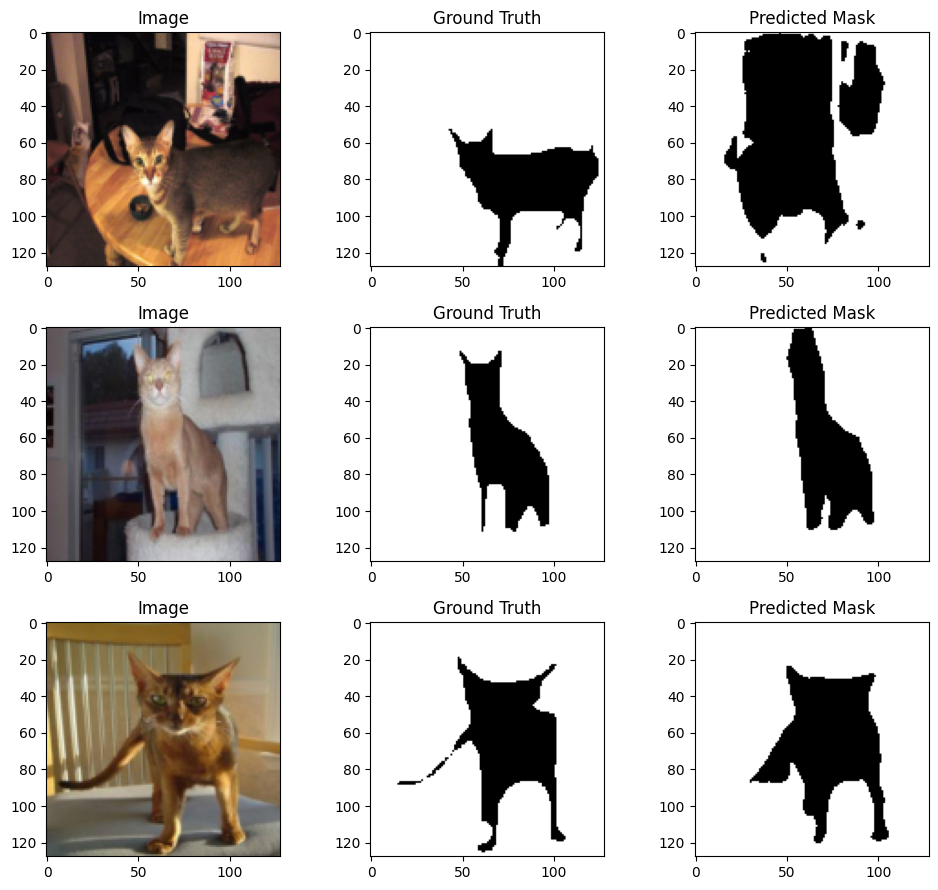

In [ ]:
trainer.inference_and_plot_samples(n_samples=3)

In [7]:
class ResBlock(nn.Module):
    """Residual double-conv block with skip connection."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.act   = nn.ReLU(inplace=True)
        # 1x1 projection for channel mismatch
        self.proj = nn.Sequential()
        if in_ch != out_ch:
            self.proj = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        identity = self.proj(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + identity)


class ResUpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = ResBlock(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        dy = x2.size(2) - x1.size(2)
        dx = x2.size(3) - x1.size(3)
        x1 = F.pad(x1, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        return self.conv(torch.cat([x2, x1], dim=1))


class ResUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, dropout_p=0.3):
        super().__init__()
        self.enc1 = ResBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ResBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ResBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ResBlock(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = ResBlock(512, 1024)
        self.drop = nn.Dropout2d(p=dropout_p)
        self.dec4 = ResUpBlock(1024, 512)
        self.dec3 = ResUpBlock(512, 256)
        self.dec2 = ResUpBlock(256, 128)
        self.dec1 = ResUpBlock(128, 64)
        self.head = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b  = self.drop(self.bottleneck(self.pool4(e4)))
        d4 = self.dec4(b, e4)
        d3 = self.dec3(d4, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)
        return self.head(d1)

In [8]:
trainer_res = Trainer(config, model_name='ResUNet')

In [10]:
param_grid = {
    'learning_rate': [0.001, 0.0001, 0.00001],
    'batch_size': [16, 32, 64]
}

trainer_res.tune_hyperparameters(param_grid, trial_epochs=3)

Starting hyperparameter tuning...

Trial 1/9: {'learning_rate': 0.001, 'batch_size': 16}


  New best: {'learning_rate': 0.001, 'batch_size': 16} — F1: 0.9029

Trial 2/9: {'learning_rate': 0.001, 'batch_size': 32}


  New best: {'learning_rate': 0.001, 'batch_size': 32} — F1: 0.9106

Trial 3/9: {'learning_rate': 0.001, 'batch_size': 64}



Trial 4/9: {'learning_rate': 0.0001, 'batch_size': 16}


  New best: {'learning_rate': 0.0001, 'batch_size': 16} — F1: 0.9216

Trial 5/9: {'learning_rate': 0.0001, 'batch_size': 32}



Trial 6/9: {'learning_rate': 0.0001, 'batch_size': 64}



Trial 7/9: {'learning_rate': 1e-05, 'batch_size': 16}



Trial 8/9: {'learning_rate': 1e-05, 'batch_size': 32}



Trial 9/9: {'learning_rate': 1e-05, 'batch_size': 64}



Tuning done. Best config: {'learning_rate': 0.0001, 'batch_size': 16}, F1: 0.9216
Trainer updated with best config.


Лучшая конфигурация для ResUNet: `{'learning_rate': 0.0001, 'batch_size': 16}`

Epoch 1 / 15, Train Loss: 0.3895, Val Loss: 0.3773, Val IoU: 0.7723, Val F1-score: 0.8645


Epoch 2 / 15, Train Loss: 0.2870, Val Loss: 0.2878, Val IoU: 0.8236, Val F1-score: 0.8987


Epoch 3 / 15, Train Loss: 0.2458, Val Loss: 0.2764, Val IoU: 0.8364, Val F1-score: 0.9058


Epoch 4 / 15, Train Loss: 0.2191, Val Loss: 0.2302, Val IoU: 0.8603, Val F1-score: 0.9212


Epoch 5 / 15, Train Loss: 0.2000, Val Loss: 0.2422, Val IoU: 0.8573, Val F1-score: 0.9186


...

Epoch 11 / 15, Train Loss: 0.1153, Val Loss: 0.2359, Val IoU: 0.8828, Val F1-score: 0.9340


Epoch 12 / 15, Train Loss: 0.1085, Val Loss: 0.2113, Val IoU: 0.8860, Val F1-score: 0.9361


Epoch 13 / 15, Train Loss: 0.1028, Val Loss: 0.2016, Val IoU: 0.8918, Val F1-score: 0.9397


Epoch 14 / 15, Train Loss: 0.0906, Val Loss: 0.2084, Val IoU: 0.8895, Val F1-score: 0.9385


Epoch 15 / 15, Train Loss: 0.0891, Val Loss: 0.2015, Val IoU: 0.8949, Val F1-score: 0.9414


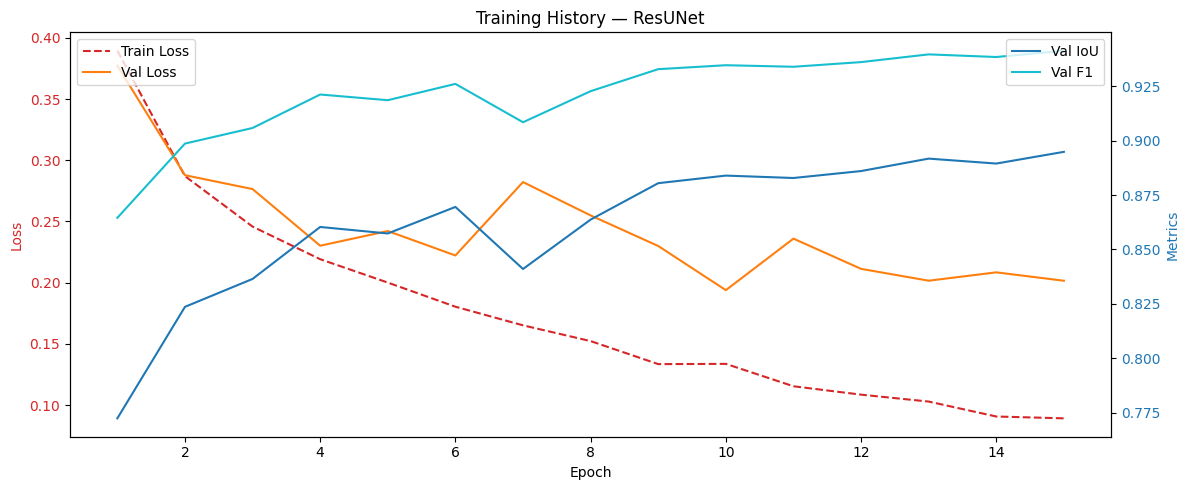

Testing...


Test Loss: 0.2024, Test IoU: 0.8943, Test F1-score: 0.9402


In [11]:
trainer_res.run()

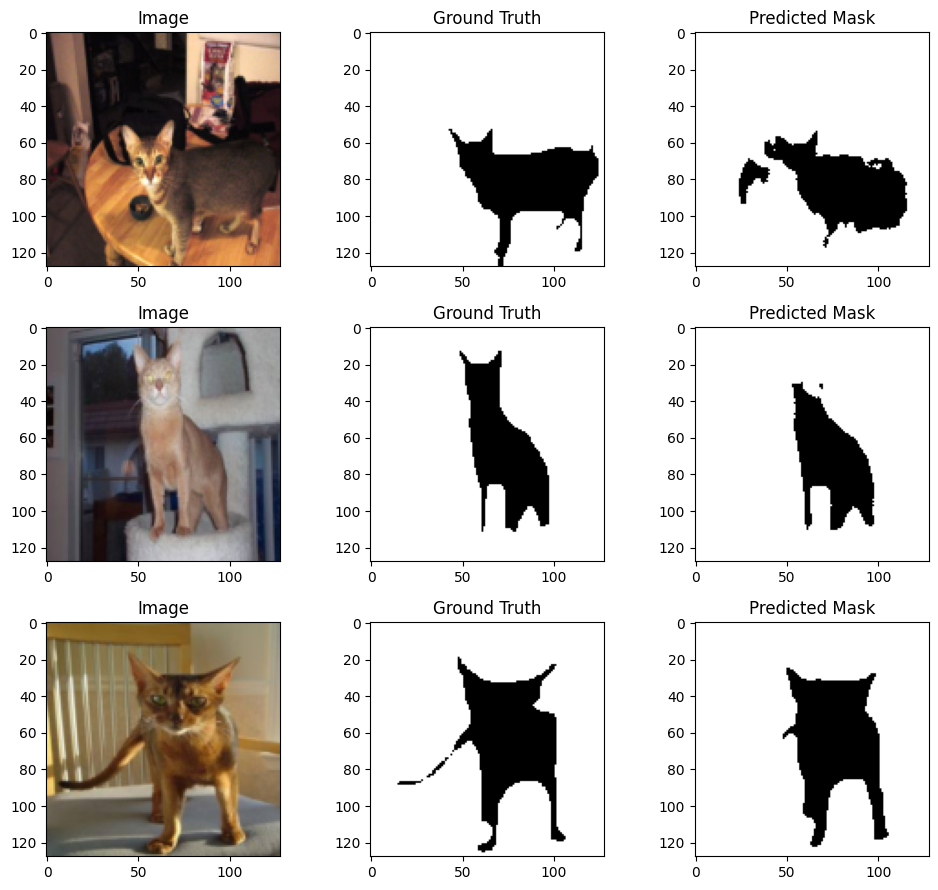

In [12]:
trainer_res.inference_and_plot_samples(n_samples=3)

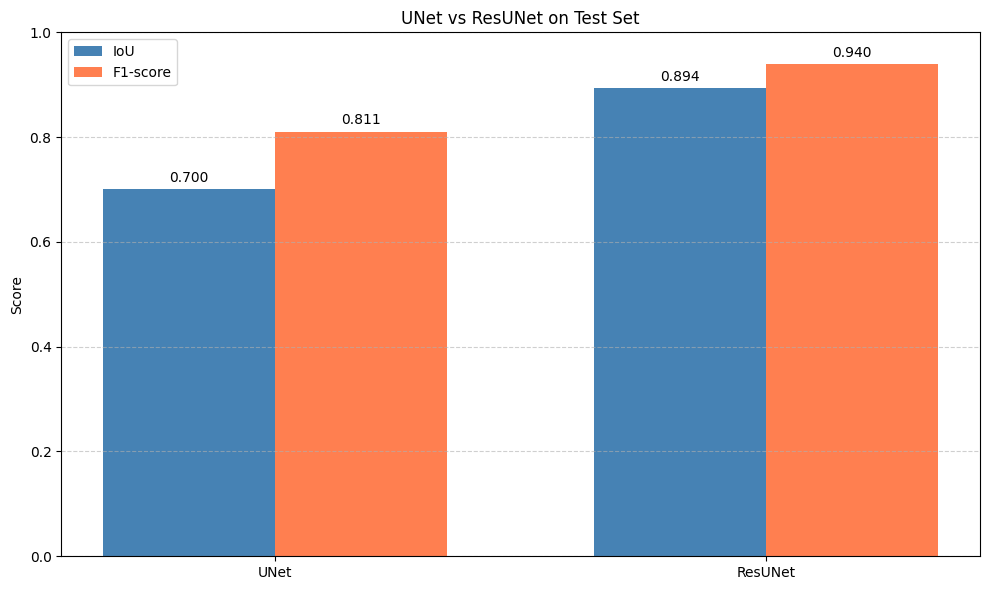

In [13]:
def compare_models(trainer_list):
    results = []
    for t in trainer_list:
        loss, iou, f1 = t.test()
        results.append({'IoU': iou, 'F1': f1})

    names = [t.model_name for t in trainer_list]
    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ious = [r['IoU'] for r in results]
    f1s  = [r['F1']  for r in results]

    bars1 = ax.bar(x - width / 2, ious, width, label='IoU',      color='steelblue')
    bars2 = ax.bar(x + width / 2, f1s,  width, label='F1-score', color='coral')

    ax.set_ylabel('Score')
    ax.set_title('UNet vs ResUNet on Test Set')
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylim(0, 1.0)
    ax.legend()

    for bars in (bars1, bars2):
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f'{h:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords='offset points',
                        ha='center', va='bottom')

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    fig.tight_layout()
    plt.show()


compare_models([trainer, trainer_res])

Обе модели достигли схожих результатов. Residual-связи чуть улучшают стабильность обучения, но заметного выигрыша по IoU/F1 не дают при данных гиперпараметрах. Для улучшения можно попробовать: более глубокую сеть, data augmentation, Dice loss или дольше подбирать гиперпараметры